In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [6]:
titanic = sns.load_dataset("titanic")

features = ["pclass", "sex", "fare", "embarked", "age"]
target = "survived"

# Handle missing data
imp_median = SimpleImputer(strategy="median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

imp_freq = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])

# Encode
le = LabelEncoder()

titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

X = titanic[features]
y = titanic["survived"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [7]:
# Decision Tree

model = DecisionTreeClassifier()

model.fit(X_train, y_train)

y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

print("Training accuracy: ", accuracy_score(y_train, y_pred_train) * 100, "%")
print("Testing accuracy: ", accuracy_score(y_test, y_pred_test) * 100, "%")


#CLASSIC CASE OF OVERFITTING

Training accuracy:  97.91332263242376 %
Testing accuracy:  75.3731343283582 %


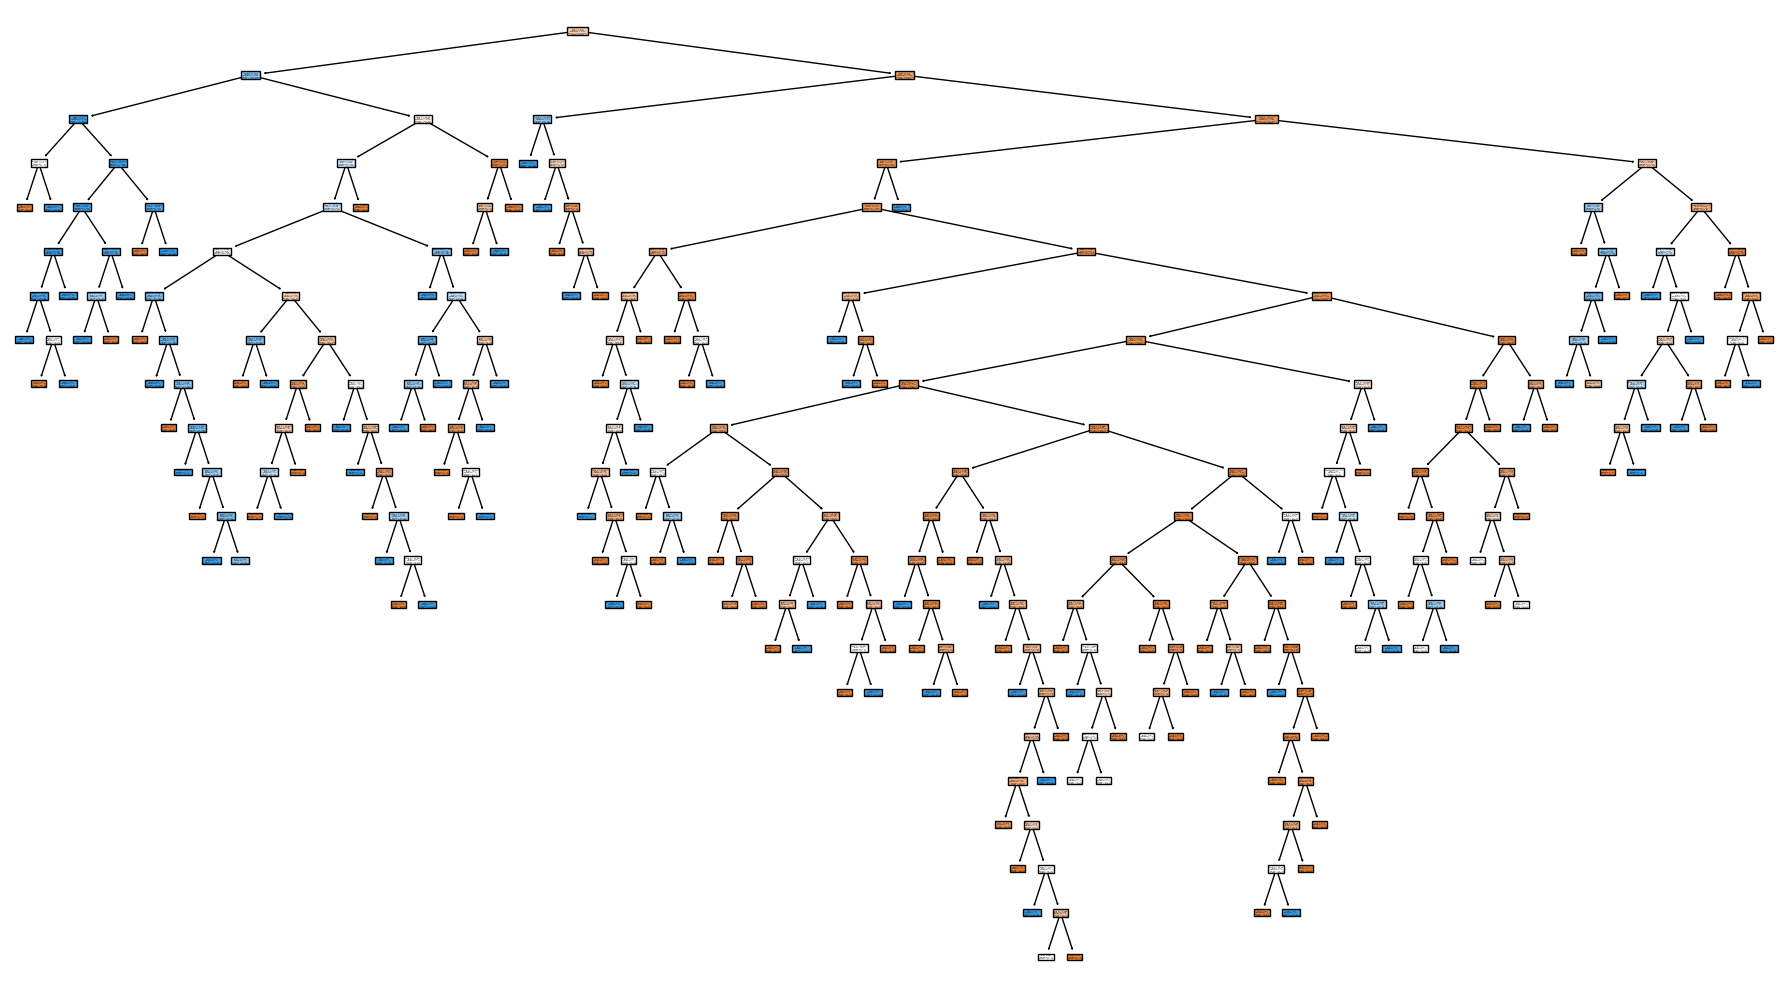

In [8]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True
)

plt.tight_layout()

In [10]:
# RANDOM FOREST CLASSIFIER
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=501,
    oob_score=True
    
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("OOB Score: ", rf.oob_score_)
print("testing accuracy: ", accuracy_score(y_test, y_pred))

OOB Score:  0.8073836276083467
testing accuracy:  0.7723880597014925


In [11]:
# Bagging Classifier
from sklearn.ensemble import BaggingClassifier

base_model = DecisionTreeClassifier()

bagging = BaggingClassifier(
    base_model,
    n_estimators=201
)
bagging.fit(X_train, y_train)

y_pred_test = bagging.predict(X_test)
print("testing accuracy: ", accuracy_score(y_test, y_pred))

testing accuracy:  0.7723880597014925


In [15]:
# Bagging Classifier
from sklearn.linear_model import LogisticRegression

base_model = LogisticRegression(max_iter=1000)

bagging = BaggingClassifier(
    base_model,
    n_estimators=201
)
bagging.fit(X_train, y_train)

y_pred = bagging.predict(X_test)

print("testing accuracy: ", accuracy_score(y_test, y_pred))

testing accuracy:  0.7947761194029851
